# Домашнее задание: Занятие 31

**Тема: Рекуррентные нейронные сети (RNN)**

В этом задании вы самостоятельно построите и обучите RNN. Каждое задание ссылается на конкретный слайд из презентации -- если забыли, вернитесь к нему.

---

## Часть 1: Теория

Отвечайте своими словами, не копируйте.

### Вопрос 1

*(Слайды 4-5)*

В чем ключевое отличие RNN от FCNN и CNN? Почему FCNN не подходит для работы с текстом или временными рядами? Приведите свой пример последовательности, где порядок элементов критически важен.

**Ваш ответ:** RNN обладает памятью. Она учитывает предыдущие элементы, в то время как FCNN и CNN обычно обрабатывают каждый вход независимо. FCNN ожидает вход фиксированного размера и не понимает связей между соседями. В тексте слово "не" меняет смысл всей фразы, а FCNN просто увидит набор признаков. Например, предложение "Казнить нельзя помиловать", от позиции запятой полностью меняется смысл



### Вопрос 2

*(Слайды 7, 9-10)*

Опишите, что такое hidden state (скрытое состояние). Как оно обновляется на каждом шаге? Напишите формулу обновления hidden state и объясните каждый элемент формулы.

**Ваш ответ:** Hidden state - это контекст нейросети, в котором она хранит краткое содержание всего, что видела ранее. Формула: $$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$$




### Вопрос 3

*(Слайд 12)*

Перечислите три типа RNN архитектур (One-to-Many, Many-to-One, Many-to-Many). Для каждого типа:
- опишите формат входа и выхода
- приведите пример реальной задачи

**Ваш ответ:**
1. One-to-Many: 1 вход, на выходе последовательность. Например, создание описания к одной картинке
2. Many-to-One: на входе последовательность и 1 выход. Например, определение типа отзыва позитивный/негативный
3. Many-to-Many: последовательности на входе и выходе. Например, машинный перевод, фраза на одном языке во фразу на другом


### Вопрос 4

*(Слайды 19-20)*

Что такое vanishing gradient в контексте RNN? Почему эта проблема усиливается при длинных последовательностях? Что такое BPTT?

**Ваш ответ:** Vanishing gradient - это когда в RNN ошибка просачивается назад сквозь время. Если цепочка длинная, значения ошибки многократно умножаются на малые числа и превращаются в ноль. Сеть перестает обновлять веса для начала длинной фразы. BPTT - это стандартный алгоритм обучения нейросетей, адаптированный под RNN. Мы разворачиваем сеть в длинную цепь и считаем производные по всей длине последовательности



### Вопрос 5

*(Слайд 16)*

У нас есть `nn.RNN(input_size=10, hidden_size=64, num_layers=1, batch_first=True)`. На вход подается тензор размера `(8, 50, 10)`. Какой размер будет у:
- output (все шаги)
- hidden (финальное состояние)

Что поменяется, если `num_layers=2`?

**Ваш ответ:**
- Output: (8, 50, 64) - результат для каждого из 50 шагов
- Hidden: (1, 8, 64) - только последнее состояние

Для num_layers=2:
- Output: Размер останется (8, 50, 64), так как это выход последнего слоя
- Hidden: Станет (2, 8, 64), так как теперь у нас есть финальное состояние для каждого из двух слоев



---

## Часть 2: Код

### Подготовка

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


### Задание 1: Сгенерируйте данные

Создайте более сложный сигнал: сумму двух синусоид с разными частотами. Нарежьте на окна длиной 30.

Формула: `y = sin(t) + 0.5 * sin(3*t)`

X_train: torch.Size([776, 30, 1])
y_train: torch.Size([776, 1])


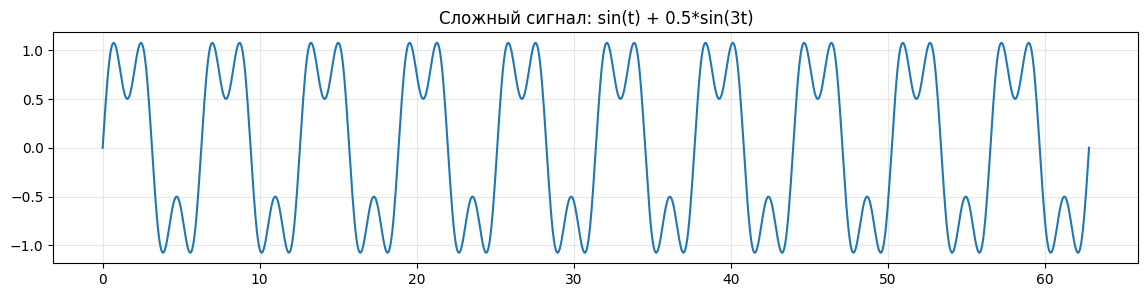

In [2]:
t = np.linspace(0, 20 * np.pi, 1000)
data = np.sin(t) + 0.5 * np.sin(3 * t)

SEQ_LEN = 30

def create_sequences(data, seq_len):
    xs = []
    ys = []
    for i in range(len(data) - seq_len):
        x = data[i:(i + seq_len)]
        y = data[i + seq_len]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(data, SEQ_LEN)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.from_numpy(X_train).float().unsqueeze(-1)
y_train_t = torch.from_numpy(y_train).float().unsqueeze(-1)

X_test_t = torch.from_numpy(X_test).float().unsqueeze(-1)
y_test_t = torch.from_numpy(y_test).float().unsqueeze(-1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

print(f'X_train: {X_train_t.shape}')
print(f'y_train: {y_train_t.shape}')

plt.figure(figsize=(14, 3))
plt.plot(t, data)
plt.title('Сложный сигнал: sin(t) + 0.5*sin(3t)')
plt.grid(alpha=0.3)
plt.show()

### Задание 2: Постройте RNN модель

*(Слайд 15)*

Напишите класс MyRNN с такими параметрами:
- input_size = 1
- hidden_size = 64
- output_size = 1
- Добавьте Dropout между RNN и Linear слоем (p=0.2) для регуляризации

In [3]:
class MyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, h_n = self.rnn(x)
        last_out = out[:, -1, :]
        x = self.dropout(last_out)
        x = self.fc(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MyRNN(1, 64, 1).to(device)

print(model)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

MyRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Параметров: 4,353


### Задание 3: Проверьте размеры

*(Слайд 16)*

Пропустите тензор `torch.randn(4, 30, 1)` через модель. Выведите размеры на каждом этапе: вход, выход RNN, выход модели.

In [4]:
x = torch.randn(4, 30, 1).to(device)
print(f'1. Вход (тестовый батч): {x.shape}')

with torch.no_grad():
    out_rnn, h_n = model.rnn(x)
    print(f'2. Выход RNN (все шаги): {out_rnn.shape}')
    print(f'3. Финальное скрытое состояние (h_n): {h_n.shape}')

    last_step = out_rnn[:, -1, :]
    print(f'4. Последний шаг для FC-слоя: {last_step.shape}')

    prediction = model(x)
    print(f'5. Итоговый выход модели: {prediction.shape}') # (batch, output_size)

1. Вход (тестовый батч): torch.Size([4, 30, 1])
2. Выход RNN (все шаги): torch.Size([4, 30, 64])
3. Финальное скрытое состояние (h_n): torch.Size([1, 4, 64])
4. Последний шаг для FC-слоя: torch.Size([4, 64])
5. Итоговый выход модели: torch.Size([4, 1])


### Задание 4: Обучите модель

*(Слайд 18)*

Напишите training loop на 80 эпох. Используйте:
- MSELoss
- Adam с lr=0.001

Сохраняйте train_loss и test_loss на каждой эпохе.

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 80
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            test_loss += loss.item()

    test_losses.append(test_loss / len(test_loader))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}  Train: {train_losses[-1]:.6f}  Test: {test_losses[-1]:.6f}')

Epoch 20/80  Train: 0.004463  Test: 0.000345
Epoch 40/80  Train: 0.003760  Test: 0.000625
Epoch 60/80  Train: 0.003321  Test: 0.001194
Epoch 80/80  Train: 0.002742  Test: 0.000131


### Задание 5: Постройте графики

Постройте два графика рядом:
- Train/Test Loss по эпохам
- Предсказания vs реальные значения на тестовых данных

Есть ли признаки переобучения?

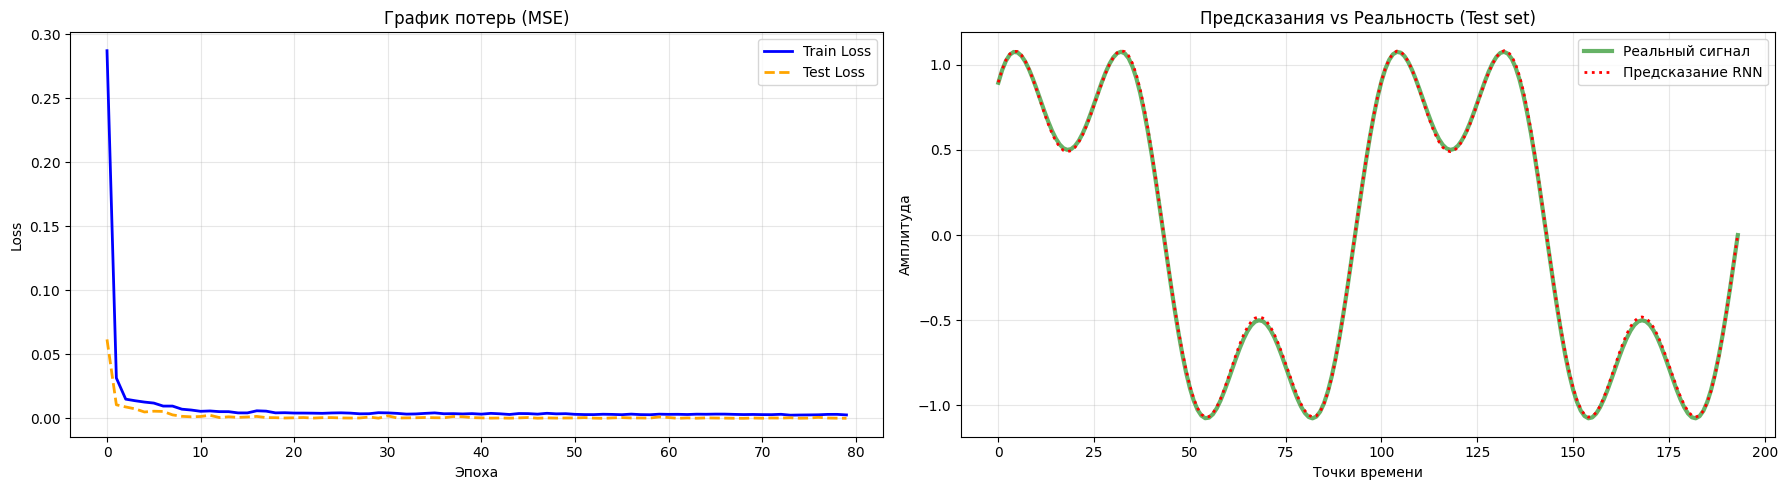

In [6]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t.to(device)).cpu().numpy()
    actuals = y_test_t.numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.plot(train_losses, label='Train Loss', color='blue', lw=2)
ax1.plot(test_losses, label='Test Loss', color='orange', linestyle='--', lw=2)
ax1.set_title('График потерь (MSE)')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(actuals, label='Реальный сигнал', color='green', alpha=0.6, lw=3)
ax2.plot(predictions, label='Предсказание RNN', color='red', linestyle=':', lw=2)
ax2.set_title('Предсказания vs Реальность (Test set)')
ax2.set_xlabel('Точки времени')
ax2.set_ylabel('Амплитуда')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Ваш вывод:** Переобучения нет, так как Train loss и Test loss обе падают


### Задание 6: Сравнение RNN vs LSTM

*(Слайд 21)*

Создайте аналогичную модель, но с nn.LSTM вместо nn.RNN. Обучите на тех же данных и сравните:
- Скорость сходимости (графики loss)
- Финальную ошибку (MAE на тесте)

Какая модель лучше? Почему?

Финальная MAE (LSTM): 0.018590


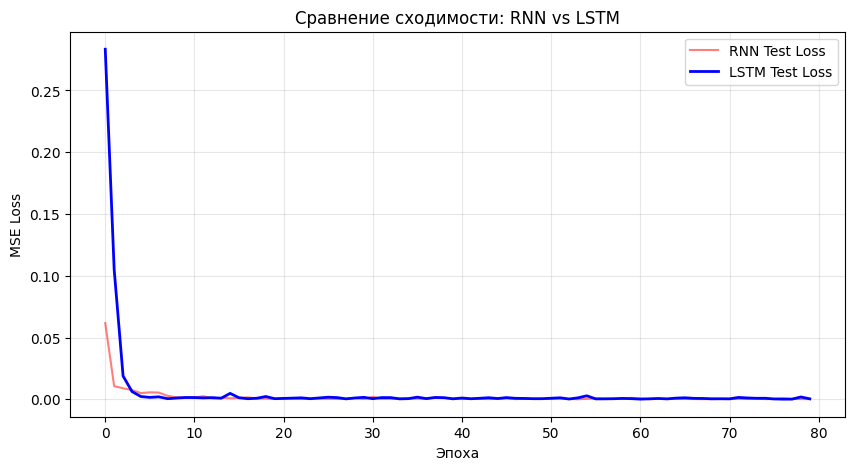

In [8]:
from sklearn.metrics import mean_absolute_error

class MyLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_out = out[:, -1, :]
        x = self.dropout(last_out)
        return self.fc(x)

model_lstm = MyLSTM(1, 64, 1).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion = nn.MSELoss()

lstm_train_losses = []
lstm_test_losses = []

for epoch in range(80):
    model_lstm.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model_lstm(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer_lstm.zero_grad()
        loss.backward()
        optimizer_lstm.step()
        epoch_loss += loss.item()

    lstm_train_losses.append(epoch_loss / len(train_loader))

    model_lstm.eval()
    t_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_lstm(X_batch)
            t_loss += criterion(outputs, y_batch).item()
    lstm_test_losses.append(t_loss / len(test_loader))

model_lstm.eval()
with torch.no_grad():
    preds_lstm = model_lstm(X_test_t.to(device)).cpu().numpy()
    mae_lstm = mean_absolute_error(y_test_t.numpy(), preds_lstm)

print(f"Финальная MAE (LSTM): {mae_lstm:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(test_losses, label='RNN Test Loss', color='red', alpha=0.5)
plt.plot(lstm_test_losses, label='LSTM Test Loss', color='blue', lw=2)
plt.title('Сравнение сходимости: RNN vs LSTM')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Ваш вывод:** LSTM лучше, потому что она умеет забывать ненужный шум и фокусироваться на важных паттернах сигнала



---

## Часть 3: Бонус

### Бонус 1: Эксперимент с длиной окна

Обучите три модели с разной длиной окна: SEQ_LEN = 10, 30, 50. Как длина окна влияет на качество? При какой длине модель работает лучше всего для нашего сигнала?

In [ ]:
# Ваш код здесь



### Бонус 2: Многошаговое предсказание

Напишите функцию, которая берет начальное окно и генерирует 100 точек вперед (каждое предсказание подается как вход для следующего шага). Визуализируйте результат.

Подсказка: посмотрите раздел 8 в практической тетрадке.

In [ ]:
# Ваш код здесь



**Ваш вывод:**

